In [22]:
from __future__ import annotations
import pandas as pd
import hashlib
import re
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# --- 설정 (데이터 경로에 맞게 수정) ---
INPUT_CSV = Path("../data/articles/news_articles_copper_silver.csv")
OUT_DIR = Path("../data/by_keyword")
CHUNK_SIZE = 15000  # 메모리 상황에 따라 10000~20000 사이 조절

# 후보 컬럼 (원본에 있는 것만 골라 읽음)
EXPECTED_COLUMNS = [
    "id", "title", "doc_url", "all_text", "authors", "publish_date",
    "meta_site_name", "key_word", "filter_status", "description",
    "named_entities", "triples", "article_embedding"
]

# 실제 저장할 컬럼 (가벼운 것 위주로 구성)
SAVE_COLUMNS = ["id", "title", "publish_date", "authors", "key_word", "description", "doc_url"]

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"✅ 준비 완료. 출력 경로: {OUT_DIR.absolute()}")

✅ 준비 완료. 출력 경로: /Users/yejoon/Documents/ai tech/tilda_data/eda/../data/by_keyword


🔍 [검토] 읽기 가능한 컬럼: ['id', 'title', 'doc_url', 'all_text', 'authors', 'publish_date', 'meta_site_name', 'filter_status', 'description', 'article_embedding']
💾 [검토] 저장 예정 컬럼: ['id', 'title', 'publish_date', 'authors', 'description', 'doc_url']
🧐 데이터 분포 스캔 중... (대상: ['filter_status'])


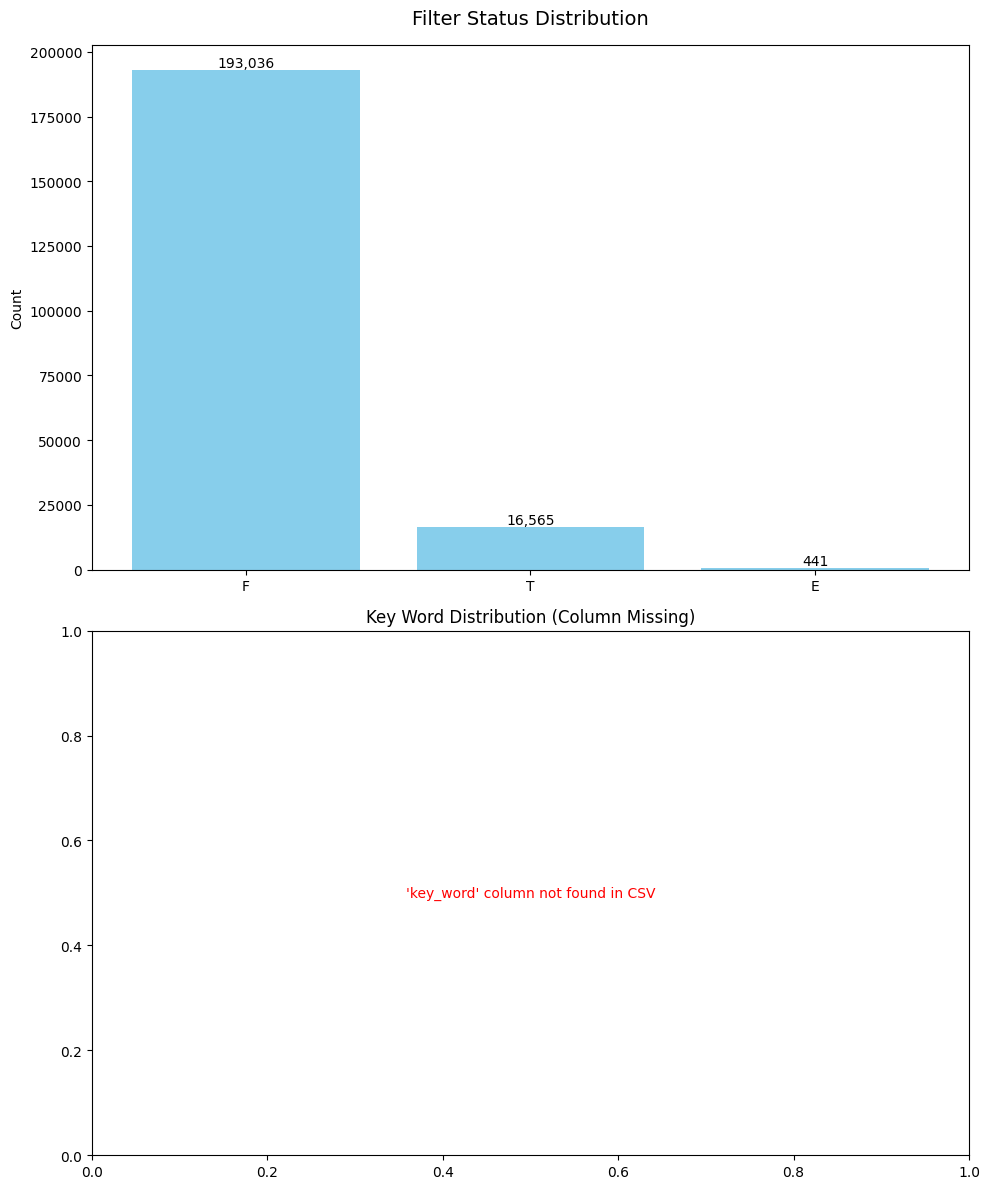


✅ 스캔 완료: 총 210,042행의 상태를 확인했습니다.


In [23]:
# --- 시각화 섹션 전체 수정본 ---

# 1. 실제 파일 컬럼 및 필터 상태 재확인
actual_header = pd.read_csv(INPUT_CSV, nrows=0).columns.tolist()
available_to_read = [c for c in EXPECTED_COLUMNS if c in actual_header]
final_save_cols = [c for c in SAVE_COLUMNS if c in actual_header]

print(f"🔍 [검토] 읽기 가능한 컬럼: {available_to_read}")
print(f"💾 [검토] 저장 예정 컬럼: {final_save_cols}")

# 2. 분포 스캔 (filter_status & key_word)
status_counts = Counter()
keyword_counts = Counter()

# 스캔할 컬럼 존재 여부 확인
scan_cols = []
if "filter_status" in actual_header: scan_cols.append("filter_status")
if "key_word" in actual_header: scan_cols.append("key_word")

if not scan_cols:
    print("❌ 에러: 분석할 'filter_status'나 'key_word' 컬럼이 파일에 없습니다.")
else:
    print(f"🧐 데이터 분포 스캔 중... (대상: {scan_cols})")
    for ch in pd.read_csv(INPUT_CSV, usecols=scan_cols, chunksize=CHUNK_SIZE):
        if "filter_status" in ch.columns:
            status_counts.update(ch["filter_status"].dropna().astype(str))
        if "key_word" in ch.columns:
            # 결측치를 명시적으로 처리하여 'got 0' 에러 방지
            keyword_counts.update(ch["key_word"].fillna("None/Empty").astype(str))

# 3. 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# --- Filter Status 그래프 ---
if status_counts:
    s_labels, s_values = zip(*status_counts.most_common())
    ax1.bar(s_labels, s_values, color='skyblue')
    ax1.set_title("Filter Status Distribution", fontsize=14, pad=15)
    ax1.set_ylabel("Count")
    # 수치 표시
    for i, v in enumerate(s_values):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom')
else:
    ax1.text(0.5, 0.5, "No Status Data Found", ha='center', va='center', fontsize=12)
    ax1.set_title("Filter Status Distribution (Empty)")

# --- Key Word 그래프 (에러 발생 지점 수정) ---
if keyword_counts:
    # 가장 빈번한 20개 추출
    top_items = keyword_counts.most_common(20)
    
    # zip 연산 전 데이터 존재 여부 최종 확인
    if top_items:
        kw_labels, kw_values = zip(*top_items)
        
        # 가독성을 위해 가로 막대 그래프 사용
        y_pos = range(len(kw_labels))
        ax2.barh(y_pos, kw_values, color='coral')
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(kw_labels)
        ax2.invert_yaxis()  # 높은 순위가 위로 오게 함
        
        ax2.set_title(f"Top {len(kw_labels)} Key Words Distribution", fontsize=14, pad=15)
        ax2.set_xlabel("Count")
        
        # 수치 표시
        for i, v in enumerate(kw_values):
            ax2.text(v, i, f' {v:,}', va='center')
    else:
        ax2.text(0.5, 0.5, "Keyword values are all null or empty", ha='center', va='center')
else:
    ax2.text(0.5, 0.5, "'key_word' column not found in CSV", ha='center', va='center', color='red')
    ax2.set_title("Key Word Distribution (Column Missing)")

plt.tight_layout()
plt.show()

print(f"\n✅ 스캔 완료: 총 {sum(status_counts.values()):,}행의 상태를 확인했습니다.")

In [24]:
def get_safe_filename(keyword):
    if pd.isna(keyword) or str(keyword).strip() == "": return "unclassified"
    clean = re.sub(r'[^\w\s-]', '', str(keyword)).strip().replace(' ', '_')
    return clean if clean else "unclassified"

def fast_hash_ids(titles, descriptions, length=16):
    """apply보다 수배 빠른 리스트 컴프리헨션 방식"""
    return [
        hashlib.sha256(f"{str(t)}|{str(d)}".encode('utf-8')).hexdigest()[:length] 
        for t, d in zip(titles, descriptions)
    ]   

written_files = set()
export_stats = Counter()
total_seen, total_written = 0, 0

print("🚀 작업을 시작합니다 (최적화 모드)...")

# 데이터 읽기 엔진을 'c'로 설정하여 속도 향상
chunks = pd.read_csv(INPUT_CSV, usecols=available_to_read, chunksize=CHUNK_SIZE, engine='c', low_memory=False)

for i, chunk in enumerate(chunks, 1):
    total_seen += len(chunk)
    
    # 1. 고속 필터링 (T인 것만)
    if "filter_status" in chunk.columns:
        chunk = chunk[chunk["filter_status"].values == "T"].copy()
    if chunk.empty: continue

    # 2. 고속 해시 생성
    chunk['id'] = fast_hash_ids(chunk['title'].values, chunk['description'].values)

    # 3. 스마트 저장 로직
    if "key_word" in chunk.columns and chunk["key_word"].notna().any():
        for key, grp in chunk.groupby("key_word", sort=False, dropna=False):
            filename = get_safe_filename(key)
            save_path = OUT_DIR / f"{filename}.csv"
            
            exists = save_path in written_files or save_path.exists()
            grp[final_save_cols].to_csv(
                save_path, mode='a', index=False, header=not exists,
                encoding='utf-8', quoting=csv.QUOTE_MINIMAL, escapechar='\\'
            )
            written_files.add(save_path)
            export_stats[filename] += len(grp)
            total_written += len(grp)
    else:
        # 키워드 없는 경우 단일 파일
        save_path = OUT_DIR / "consolidated_articles.csv"
        exists = save_path in written_files or save_path.exists()
        chunk[final_save_cols].to_csv(
            save_path, mode='a', index=False, header=not exists,
            encoding='utf-8', quoting=csv.QUOTE_MINIMAL, escapechar='\\'
        )
        written_files.add(save_path)
        export_stats["consolidated"] += len(chunk)
        total_written += len(chunk)

    if i % 10 == 0:
        print(f"📦 [Chunk {i}] 누적 확인: {total_seen:,} | 누적 저장: {total_written:,}")

# --- 결과 리포트 ---
print(f"\n✨ 완료! 총 {total_written:,}행이 {len(written_files)}개의 파일로 저장되었습니다.")
print("-" * 50)
print(f"{'파일명':<25} | {'저장된 행 수':>10}")
for fname, count in export_stats.most_common(20):
    print(f"{fname[:25]:<25} | {count:>10,}")

🚀 작업을 시작합니다 (최적화 모드)...
📦 [Chunk 10] 누적 확인: 150,000 | 누적 저장: 9,826

✨ 완료! 총 16,565행이 1개의 파일로 저장되었습니다.
--------------------------------------------------
파일명                       |    저장된 행 수
consolidated              |     16,565


In [34]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

files = [
    f for f in os.listdir(PROJECT_ROOT/"../data/by_keyword")
]
for f in files:
    print(f'"{f}",')

"sorghum_and_price_or_demand_or_supply_or_inventory.csv",
"soy_oil_and_production_or_outputs_or_supplies_or_supply_or_biofuel_or_biodiesel_or_demand_or_price.csv",
"soybean_oil_and_production_or_outputs_or_supplies_or_supply_or_biofuel_or_biodiesel_or_demand_or_price.csv",
"copper_silver.csv",
"soybean_and_price_or_demand_or_supply_or_inventory.csv",
"rice_and_price_or_demand_or_supply_or_inventory.csv",
"gold_future.csv",
"fomc_and_fed.csv",
"united_states_department_of_agriculture.csv",
"soybean_production.csv",
"wheat_and_price_or_demand_or_supply_or_inventory.csv",
"corn_and_price_or_demand_or_supply_or_inventory.csv",
"national_agricultural_statistics_service.csv",
